# Information Routing in Deep Neural Networks
### Capsule Networks (dynamic routing) vs. Vision Transformers (self-attention)

## 0. Install dependencies


In [1]:
!pip install torch torchvision matplotlib numpy --quiet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


## 1. Imports


In [2]:
import os, json, time, argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
os.makedirs('outputs', exist_ok=True)
print('device =', device)


device = mps


## 2. System A — Capsule Network (dynamic routing)
`DigitCapsules.forward` is the routing-by-agreement loop; the coupling matrix $c_{ij}$ is stored in `last_coupling` for Visualization A.


In [3]:
def squash(s, dim=-1, eps=1e-8):
    """
    Non-linear 'squashing' activation for capsules.

        v = (||s||^2 / (1 + ||s||^2)) * (s / ||s||)

    Short vectors are shrunk toward 0, long vectors toward (just under) 1,
    so the *length* of a capsule's output behaves like a probability that
    the entity it represents is present, while its *orientation* encodes pose.
    """
    sq_norm = (s ** 2).sum(dim=dim, keepdim=True)
    scale = sq_norm / (1.0 + sq_norm)
    return scale * s / torch.sqrt(sq_norm + eps)


class PrimaryCapsules(nn.Module):
    """
    Convolutional layer that produces the lowest-level capsules.
    Output is a set of 8-D capsules, one group per spatial location.
    """

    def __init__(self, in_channels=256, out_caps_types=32, caps_dim=8,
                 kernel_size=9, stride=2):
        super().__init__()
        self.caps_dim = caps_dim
        self.out_caps_types = out_caps_types
        self.conv = nn.Conv2d(in_channels, out_caps_types * caps_dim,
                              kernel_size=kernel_size, stride=stride)

    def forward(self, x):
        out = self.conv(x)                       # [B, types*dim, H, W]
        B = out.size(0)
        # reshape into individual capsules of dimension caps_dim
        out = out.view(B, self.out_caps_types, self.caps_dim, out.size(2), out.size(3))
        out = out.permute(0, 1, 3, 4, 2).contiguous()   # [B, types, H, W, dim]
        out = out.view(B, -1, self.caps_dim)            # [B, num_primary, dim]
        return squash(out, dim=-1)


class DigitCapsules(nn.Module):
    """
    Higher-level capsules computed by *dynamic routing-by-agreement*.

    Each lower capsule i makes a prediction u_hat_{j|i} = W_ij u_i for every
    higher capsule j. The coupling coefficients c_ij are refined over several
    routing iterations so that each lower capsule sends most of its output to
    the higher capsule whose current output v_j it best agrees with.
    """

    def __init__(self, num_primary, in_dim=8, num_classes=10, out_dim=16,
                 num_routing=3):
        super().__init__()
        self.num_primary = num_primary
        self.num_classes = num_classes
        self.out_dim = out_dim
        self.num_routing = num_routing
        # one transformation matrix W_ij per (primary i, class j) pair
        self.W = nn.Parameter(0.01 * torch.randn(1, num_primary, num_classes,
                                                  out_dim, in_dim))
        # placeholder so the last routing coefficients can be inspected
        self.last_coupling = None

    def forward(self, u):
        B = u.size(0)
        # u: [B, num_primary, in_dim] -> [B, num_primary, 1, in_dim, 1]
        u = u.unsqueeze(2).unsqueeze(-1)
        # predictions u_hat_{j|i}: [B, num_primary, num_classes, out_dim, 1]
        u_hat = torch.matmul(self.W, u).squeeze(-1)       # [B, P, C, out_dim]

        # routing logits b_ij start at zero (uniform coupling)
        b = torch.zeros(B, self.num_primary, self.num_classes, device=u.device)

        # detach predictions during the inner routing iterations: gradients flow
        # only through the final iteration (standard practice for stability)
        u_hat_detached = u_hat.detach()

        v = None
        for r in range(self.num_routing):
            # softmax over the parent classes j  ->  sum_j c_ij = 1
            c = F.softmax(b, dim=2)                        # [B, P, C]
            use_hat = u_hat if r == self.num_routing - 1 else u_hat_detached
            s = (c.unsqueeze(-1) * use_hat).sum(dim=1)     # [B, C, out_dim]
            v = squash(s, dim=-1)                          # [B, C, out_dim]
            if r < self.num_routing - 1:
                # agreement = dot product of prediction and current parent output
                agreement = (use_hat * v.unsqueeze(1)).sum(dim=-1)   # [B, P, C]
                b = b + agreement

        self.last_coupling = c.detach()   # [B, num_primary, num_classes]
        return v                          # [B, num_classes, out_dim]


class CapsuleNetwork(nn.Module):
    """Full Capsule Network with an optional reconstruction decoder."""

    def __init__(self, in_channels=1, image_size=28, num_classes=10,
                 num_routing=3, use_reconstruction=True):
        super().__init__()
        self.num_classes = num_classes
        self.image_size = image_size
        self.in_channels = in_channels
        self.use_reconstruction = use_reconstruction

        self.conv1 = nn.Conv2d(in_channels, 256, kernel_size=9, stride=1)
        self.relu = nn.ReLU(inplace=True)
        self.primary = PrimaryCapsules(256, out_caps_types=32, caps_dim=8,
                                       kernel_size=9, stride=2)

        # work out how many primary capsules the chosen image size yields
        size1 = image_size - 8                     # after conv1 (k=9, s=1)
        size2 = (size1 - 9) // 2 + 1               # after primary (k=9, s=2)
        num_primary = 32 * size2 * size2
        self.num_primary = num_primary

        self.digit = DigitCapsules(num_primary, in_dim=8,
                                   num_classes=num_classes, out_dim=16,
                                   num_routing=num_routing)

        if use_reconstruction:
            self.decoder = nn.Sequential(
                nn.Linear(16 * num_classes, 512), nn.ReLU(inplace=True),
                nn.Linear(512, 1024), nn.ReLU(inplace=True),
                nn.Linear(1024, in_channels * image_size * image_size),
                nn.Sigmoid(),
            )

    def forward(self, x, y=None):
        x = self.relu(self.conv1(x))
        x = self.primary(x)
        v = self.digit(x)                          # [B, num_classes, 16]
        lengths = v.norm(dim=-1)                   # [B, num_classes] = class probs

        recon = None
        if self.use_reconstruction:
            if y is None:
                idx = lengths.argmax(dim=1)
            else:
                idx = y
            mask = F.one_hot(idx, self.num_classes).float().unsqueeze(-1)
            recon = self.decoder((v * mask).view(v.size(0), -1))
            recon = recon.view(-1, self.in_channels, self.image_size, self.image_size)
        return lengths, v, recon

    def get_routing_coefficients(self):
        """Return c_ij from the most recent forward pass (Visualization A)."""
        return self.digit.last_coupling


def margin_loss(lengths, targets, m_pos=0.9, m_neg=0.1, lam=0.5):
    """Margin loss of Sabour et al. (2017)."""
    t = F.one_hot(targets, lengths.size(1)).float()
    pos = t * F.relu(m_pos - lengths) ** 2
    neg = lam * (1 - t) * F.relu(lengths - m_neg) ** 2
    return (pos + neg).sum(dim=1).mean()


def capsnet_loss(lengths, recon, targets, images, recon_scale=0.0005):
    """Total loss = margin loss + (optional) reconstruction loss."""
    loss = margin_loss(lengths, targets)
    if recon is not None:
        loss = loss + recon_scale * F.mse_loss(recon, images, reduction='sum') / images.size(0)
    return loss


## 3. System B — Vision Transformer (self-attention)
`MultiHeadSelfAttention.forward` computes $\alpha_{ij}$ and stores it in `last_attention` for Visualization B.


In [4]:
class PatchEmbedding(nn.Module):
    """Split the image into non-overlapping patches and linearly embed them."""

    def __init__(self, in_channels=1, image_size=28, patch_size=7, embed_dim=64):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.num_patches = (image_size // patch_size) ** 2
        self.grid = image_size // patch_size
        # a strided conv is exactly a per-patch linear projection
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                        # [B, embed_dim, grid, grid]
        x = x.flatten(2).transpose(1, 2)        # [B, num_patches, embed_dim]
        return x


class MultiHeadSelfAttention(nn.Module):
    """
    Scaled dot-product multi-head self-attention.

        alpha_ij = softmax_j( q_i . k_j / sqrt(d_head) )
        out_i    = sum_j alpha_ij v_j

    The softmax runs over the key index j, so for every query token i the
    weights alpha_i,: form a distribution (sum_j alpha_ij = 1).
    """

    def __init__(self, embed_dim=64, num_heads=4, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.drop = nn.Dropout(dropout)
        self.last_attention = None

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)          # [3, B, heads, N, head_dim]
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = (q @ k.transpose(-2, -1)) * self.scale     # [B, heads, N, N]
        attn = scores.softmax(dim=-1)                       # alpha_ij
        self.last_attention = attn.detach()                 # store for viz
        attn = self.drop(attn)

        out = attn @ v                                      # [B, heads, N, head_dim]
        out = out.transpose(1, 2).reshape(B, N, C)
        return self.proj(out)


class TransformerBlock(nn.Module):
    """Pre-norm Transformer encoder block: MHSA + MLP, both residual."""

    def __init__(self, embed_dim=64, num_heads=4, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    """Compact ViT sized for MNIST / CIFAR-10."""

    def __init__(self, in_channels=1, image_size=28, patch_size=7,
                 num_classes=10, embed_dim=64, depth=4, num_heads=4,
                 mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, image_size, patch_size, embed_dim)
        n = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding (one slot per patch + the cls token)
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self.grid = self.patch_embed.grid

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])               # classify from the cls token

    def get_attention_maps(self):
        """List of attention tensors [B, heads, N, N], one per block (Viz B)."""
        return [blk.attn.last_attention for blk in self.blocks]


## 4. Data utilities
Dataset download, fractional subsets (Exp 2), Gaussian noise (Exp 3).


In [5]:
DATASET_INFO = {
    "mnist":   dict(in_channels=1, image_size=28, patch_size=7, num_classes=10),
    "cifar10": dict(in_channels=3, image_size=32, patch_size=4, num_classes=10),
}

def get_datasets(name="minist", root="./data"):
    tf = transforms.ToTensor()
    if name == "mnist":
        return (datasets.MNIST(root, train=True,  download=True, transform=tf),
                datasets.MNIST(root, train=False, download=True, transform=tf))
    return (datasets.CIFAR10(root, train=True,  download=True, transform=tf),
            datasets.CIFAR10(root, train=False, download=True, transform=tf))

def fractional_subset(dataset, fraction, seed=0):
    if fraction >= 1.0:
        return dataset
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(dataset))[: int(len(dataset) * fraction)]
    return Subset(dataset, idx.tolist())

def make_loaders(train_set, test_set, batch_size=128, fraction=1.0):
    train_set = fractional_subset(train_set, fraction)
    return (DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=True),
            DataLoader(test_set,  batch_size=batch_size, shuffle=False))

def add_gaussian_noise(images, sigma):
    if sigma <= 0:
        return images
    return (images + torch.randn_like(images) * sigma).clamp(0, 1)


## 5. Shared training / evaluation loop
Identical settings for both models = fair comparison.


In [6]:
def _is_capsnet(model):
    return model.__class__.__name__ == "CapsuleNetwork"


def train_one_epoch(model, loader, optimizer, device, noise_sigma=0.0):
    model.train()
    total_loss, correct, seen = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        if noise_sigma > 0:
            images = add_gaussian_noise(images, noise_sigma)
        optimizer.zero_grad()
        if _is_capsnet(model):
            lengths, _, recon = model(images, targets)
            loss = capsnet_loss(lengths, recon, targets, images)
            preds = lengths.argmax(dim=1)
        else:
            logits = model(images)
            loss = F.cross_entropy(logits, targets)
            preds = logits.argmax(dim=1)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (preds == targets).sum().item()
        seen += images.size(0)
    return total_loss / seen, correct / seen


@torch.no_grad()
def evaluate(model, loader, device, noise_sigma=0.0):
    model.eval()
    total_loss, correct, seen = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        if noise_sigma > 0:
            images = add_gaussian_noise(images, noise_sigma)
        if _is_capsnet(model):
            lengths, _, recon = model(images)
            loss = capsnet_loss(lengths, recon, targets, images)
            preds = lengths.argmax(dim=1)
        else:
            logits = model(images)
            loss = F.cross_entropy(logits, targets)
            preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == targets).sum().item()
        seen += images.size(0)
    return total_loss / seen, correct / seen


def fit(model, train_loader, test_loader, device, epochs=5, lr=1e-3,
        noise_sigma=0.0, log=True, tag=""):
    """Train `model` and return a per-epoch history dict."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                          device, noise_sigma)
        te_loss, te_acc = evaluate(model, test_loader, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)
        if log:
            print(f"[{tag}] epoch {ep}/{epochs}  "
                  f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  "
                  f"test_acc={te_acc:.4f}  ({time.time()-t0:.1f}s)")
    return history


## 6. Visualizations A / B / C


In [7]:
@torch.no_grad()
def visualize_routing(model, images, device, save_path, max_primary=64):
    """
    Visualization A. Runs the CapsNet on one image and plots c_ij as a heatmap
    (primary capsules on the y-axis, class capsules on the x-axis).

    Rows sum to 1: each primary capsule distributes its vote over the classes.
    A bright column => many primary capsules support that class.
    """
    model.eval()
    img = images[:1].to(device)
    lengths, _, _ = model(img)
    c = model.get_routing_coefficients()[0].cpu().numpy()   # [num_primary, num_classes]

    # show a subset of primary capsules so the heatmap stays readable
    if c.shape[0] > max_primary:
        c = c[:max_primary]

    fig, ax = plt.subplots(1, 2, figsize=(11, 5),
                           gridspec_kw={"width_ratios": [1, 2.2]})
    ax[0].imshow(img[0].cpu().permute(1, 2, 0).squeeze(), cmap="gray")
    ax[0].set_title(f"Input (pred = {lengths.argmax(1).item()})")
    ax[0].axis("off")

    im = ax[1].imshow(c, aspect="auto", cmap="viridis")
    ax[1].set_title("Routing coefficients $c_{ij}$")
    ax[1].set_xlabel("Class capsule  j")
    ax[1].set_ylabel("Primary capsule  i")
    fig.colorbar(im, ax=ax[1], fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130)
    plt.close()

    # also report total support each class receives (sum over primary capsules)
    support = c.sum(axis=0)
    return support


@torch.no_grad()
def visualize_attention(model, images, device, save_path, block=-1):
    """
    Visualization B. Plots the [N x N] attention matrix (averaged over heads)
    of one block, plus the cls-token attention reshaped over the patch grid.
    """
    model.eval()
    img = images[:1].to(device)
    _ = model(img)
    attn = model.get_attention_maps()[block][0]      # [heads, N, N]
    attn_mean = attn.mean(0).cpu().numpy()           # average over heads

    # attention paid by the cls token (row 0) to the image patches (cols 1:)
    cls_attn = attn_mean[0, 1:]
    grid = model.grid
    cls_map = cls_attn.reshape(grid, grid)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img[0].cpu().permute(1, 2, 0).squeeze(), cmap="gray")
    ax[0].set_title("Input")
    ax[0].axis("off")

    im1 = ax[1].imshow(attn_mean, cmap="magma")
    ax[1].set_title(r"Attention $\alpha_{ij}$ (all tokens)")
    ax[1].set_xlabel("Key token  j")
    ax[1].set_ylabel("Query token  i")
    fig.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(cls_map, cmap="magma")
    ax[2].set_title("CLS-token attention over patches")
    ax[2].axis("off")
    fig.colorbar(im2, ax=ax[2], fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130)
    plt.close()

    sparsity = float((attn_mean < 0.01).mean())      # fraction of near-zero weights
    return sparsity


@torch.no_grad()
def side_by_side(capsnet, vit, images, device, save_path):
    """Visualization C. Routing heatmap next to attention heatmap for the
    same input image."""
    capsnet.eval(); vit.eval()
    img = images[:1].to(device)

    capsnet(img)
    c = capsnet.get_routing_coefficients()[0].cpu().numpy()
    if c.shape[0] > 64:
        c = c[:64]

    vit(img)
    a = vit.get_attention_maps()[-1][0].mean(0).cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img[0].cpu().permute(1, 2, 0).squeeze(), cmap="gray")
    ax[0].set_title("Input"); ax[0].axis("off")

    im0 = ax[1].imshow(c, aspect="auto", cmap="viridis")
    ax[1].set_title("CapsNet routing $c_{ij}$")
    ax[1].set_xlabel("Class j"); ax[1].set_ylabel("Primary capsule i")
    fig.colorbar(im0, ax=ax[1], fraction=0.046)

    im1 = ax[2].imshow(a, cmap="magma")
    ax[2].set_title(r"Transformer attention $\alpha_{ij}$")
    ax[2].set_xlabel("Key j"); ax[2].set_ylabel("Query i")
    fig.colorbar(im1, ax=ax[2], fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130)
    plt.close()


## 7. Experiments 1 / 2 / 3


In [8]:
def _fresh(model_fn, device):
    m = model_fn().to(device)
    return m


def experiment1_classification(build_caps, build_vit, train_set, test_set,
                               device, epochs, out_dir):
    """Train both models on the full set, compare accuracy and training loss."""
    tr, te = make_loaders(train_set, test_set, fraction=1.0)
    caps = _fresh(build_caps, device)
    vit = _fresh(build_vit, device)
    h_caps = fit(caps, tr, te, device, epochs=epochs, tag="CapsNet")
    h_vit = fit(vit, tr, te, device, epochs=epochs, tag="ViT")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].plot(h_caps["train_loss"], "-o", label="CapsNet")
    ax[0].plot(h_vit["train_loss"], "-s", label="ViT")
    ax[0].set_title("Experiment 1 — training loss")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend()
    ax[1].plot(h_caps["test_acc"], "-o", label="CapsNet")
    ax[1].plot(h_vit["test_acc"], "-s", label="ViT")
    ax[1].set_title("Experiment 1 — test accuracy")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "exp1_classification.png"), dpi=130)
    plt.close()

    return {"capsnet": h_caps, "vit": h_vit}, caps, vit


def experiment2_data_efficiency(build_caps, build_vit, train_set, test_set,
                                device, epochs, out_dir,
                                fractions=(0.1, 0.25, 0.5, 1.0)):
    """Train from scratch on increasing fractions of the data."""
    results = {"fractions": list(fractions), "capsnet": [], "vit": []}
    for f in fractions:
        tr, te = make_loaders(train_set, test_set, fraction=f)
        caps = _fresh(build_caps, device)
        vit = _fresh(build_vit, device)
        hc = fit(caps, tr, te, device, epochs=epochs, log=False, tag=f"caps@{f}")
        hv = fit(vit, tr, te, device, epochs=epochs, log=False, tag=f"vit@{f}")
        results["capsnet"].append(hc["test_acc"][-1])
        results["vit"].append(hv["test_acc"][-1])
        print(f"  fraction {int(f*100):3d}% -> CapsNet {hc['test_acc'][-1]:.4f}"
              f" | ViT {hv['test_acc'][-1]:.4f}")

    plt.figure(figsize=(6.5, 4.5))
    xs = [int(f * 100) for f in fractions]
    plt.plot(xs, results["capsnet"], "-o", label="CapsNet")
    plt.plot(xs, results["vit"], "-s", label="ViT")
    plt.title("Experiment 2 — data efficiency")
    plt.xlabel("% of training data"); plt.ylabel("test accuracy"); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "exp2_data_efficiency.png"), dpi=130)
    plt.close()
    return results


def experiment3_noise(caps, vit, test_set, device, out_dir,
                      sigmas=(0.0, 0.1, 0.2, 0.3, 0.4, 0.5)):
    """Measure accuracy degradation as Gaussian noise increases (uses the
    already-trained models from Experiment 1)."""
    loader = DataLoader(test_set, batch_size=128, shuffle=False)
    results = {"sigmas": list(sigmas), "capsnet": [], "vit": []}
    for s in sigmas:
        _, ca = evaluate(caps, loader, device, noise_sigma=s)
        _, va = evaluate(vit, loader, device, noise_sigma=s)
        results["capsnet"].append(ca)
        results["vit"].append(va)
        print(f"  sigma {s:.2f} -> CapsNet {ca:.4f} | ViT {va:.4f}")

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(sigmas, results["capsnet"], "-o", label="CapsNet")
    plt.plot(sigmas, results["vit"], "-s", label="ViT")
    plt.title("Experiment 3 — noise robustness")
    plt.xlabel("Gaussian noise std (sigma)"); plt.ylabel("test accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "exp3_noise.png"), dpi=130)
    plt.close()
    return results


## 8. Advanced component (Idea 1 & Idea 2)


In [9]:
class AttentionRoutedDigitCaps(nn.Module):
    """
    Idea 1. Instead of refining c_ij by agreement over several iterations, we
    compute the coupling in ONE shot as content-based attention:

        score_ij = (q_j . u_hat_{j|i}) / sqrt(d)
        c_ij     = softmax_j(score_ij)
        v_j      = squash( sum_i c_ij u_hat_{j|i} )

    where q_j is a learned query vector for class capsule j. This makes the
    Capsule layer's routing behave like (single-pass) attention, directly
    testing the claim that attention is a special case of routing.
    """

    def __init__(self, num_primary, in_dim=8, num_classes=10, out_dim=16):
        super().__init__()
        self.num_primary = num_primary
        self.num_classes = num_classes
        self.out_dim = out_dim
        self.W = nn.Parameter(0.01 * torch.randn(1, num_primary, num_classes,
                                                  out_dim, in_dim))
        self.query = nn.Parameter(0.01 * torch.randn(num_classes, out_dim))
        self.scale = out_dim ** -0.5
        self.last_coupling = None

    def forward(self, u):
        B = u.size(0)
        u = u.unsqueeze(2).unsqueeze(-1)
        u_hat = torch.matmul(self.W, u).squeeze(-1)        # [B, P, C, out_dim]
        # attention score between each prediction and its class query
        score = (u_hat * self.query.view(1, 1, self.num_classes, self.out_dim)).sum(-1)
        score = score * self.scale                          # [B, P, C]
        c = F.softmax(score, dim=2)                         # attention as coupling
        s = (c.unsqueeze(-1) * u_hat).sum(dim=1)            # [B, C, out_dim]
        v = squash(s, dim=-1)
        self.last_coupling = c.detach()
        return v


class IterativeAttention(nn.Module):
    """
    Idea 2. Standard self-attention does a single softmax. Here we iterate:
    after computing an output we re-derive queries from it and recompute the
    attention distribution, mimicking routing-by-agreement.

        for t in 1..T:
            alpha = softmax( Q_t K^T / sqrt(d) )
            O     = alpha V
            Q_{t+1} = O   (feed the consensus back in)
    """

    def __init__(self, embed_dim=64, num_heads=4, num_iters=3):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.h = num_heads
        self.d = embed_dim // num_heads
        self.scale = self.d ** -0.5
        self.num_iters = num_iters
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.last_attention = None

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.d).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        for t in range(self.num_iters):
            attn = (q @ k.transpose(-2, -1) * self.scale).softmax(-1)
            out = attn @ v                                  # [B, h, N, d]
            q = out                                         # refine queries
        self.last_attention = attn.detach()
        out = out.transpose(1, 2).reshape(B, N, C)
        return self.proj(out)

# quick self-test of the two advanced ideas
_arc = AttentionRoutedDigitCaps(1152); print('Idea 1 out:', _arc(torch.randn(2,1152,8)).shape)
_ia = IterativeAttention(64,4,3); print('Idea 2 out:', _ia(torch.randn(2,17,64)).shape)


Idea 1 out: torch.Size([2, 10, 16])
Idea 2 out: torch.Size([2, 17, 64])


## 9. Configuration
Pick the dataset and training budget here.


In [13]:
DATASET = 'mnist'      # 'mnist' or 'cifar10'
EPOCHS  = 7
# DATASET = 'cifar10'      # 'mnist' or 'cifar10'
# EPOCHS  = 15            # try 2 for a quick test
info = DATASET_INFO[DATASET]
build_caps = lambda: CapsuleNetwork(in_channels=info['in_channels'], image_size=info['image_size'], num_classes=info['num_classes'])
build_vit  = lambda: VisionTransformer(in_channels=info['in_channels'], image_size=info['image_size'], patch_size=info['patch_size'], num_classes=info['num_classes'])
train_set, test_set = get_datasets(DATASET)
print('train size:', len(train_set), '| test size:', len(test_set))


train size: 60000 | test size: 10000


## 10. Experiment 1 — classification performance
Trains both models; saves `outputs/exp1_classification.png`.


In [14]:
exp1, caps, vit = experiment1_classification(build_caps, build_vit, train_set, test_set, device, EPOCHS, 'outputs')
print('CapsNet final test acc:', exp1['capsnet']['test_acc'][-1])
print('ViT     final test acc:', exp1['vit']['test_acc'][-1])


[CapsNet] epoch 1/7  train_loss=0.0928 train_acc=0.9278  test_acc=0.9881  (287.5s)
[CapsNet] epoch 2/7  train_loss=0.0300 train_acc=0.9898  test_acc=0.9926  (271.8s)
[CapsNet] epoch 3/7  train_loss=0.0224 train_acc=0.9939  test_acc=0.9933  (254.8s)
[CapsNet] epoch 4/7  train_loss=0.0181 train_acc=0.9959  test_acc=0.9930  (251.8s)
[CapsNet] epoch 5/7  train_loss=0.0150 train_acc=0.9971  test_acc=0.9926  (252.1s)
[CapsNet] epoch 6/7  train_loss=0.0125 train_acc=0.9982  test_acc=0.9939  (251.9s)
[CapsNet] epoch 7/7  train_loss=0.0107 train_acc=0.9989  test_acc=0.9940  (252.2s)
[ViT] epoch 1/7  train_loss=0.6778 train_acc=0.7755  test_acc=0.9243  (10.0s)
[ViT] epoch 2/7  train_loss=0.2189 train_acc=0.9349  test_acc=0.9448  (9.8s)
[ViT] epoch 3/7  train_loss=0.1554 train_acc=0.9526  test_acc=0.9657  (9.9s)
[ViT] epoch 4/7  train_loss=0.1279 train_acc=0.9610  test_acc=0.9688  (9.7s)
[ViT] epoch 5/7  train_loss=0.1064 train_acc=0.9671  test_acc=0.9702  (10.9s)
[ViT] epoch 6/7  train_loss=0.09

## 11. Visualizations A / B / C
Uses the trained models from the previous cell.


class support (routing): [6.379 6.377 6.365 6.388 6.377 6.38  6.379 6.598 6.377 6.379]
attention sparsity: 0.0


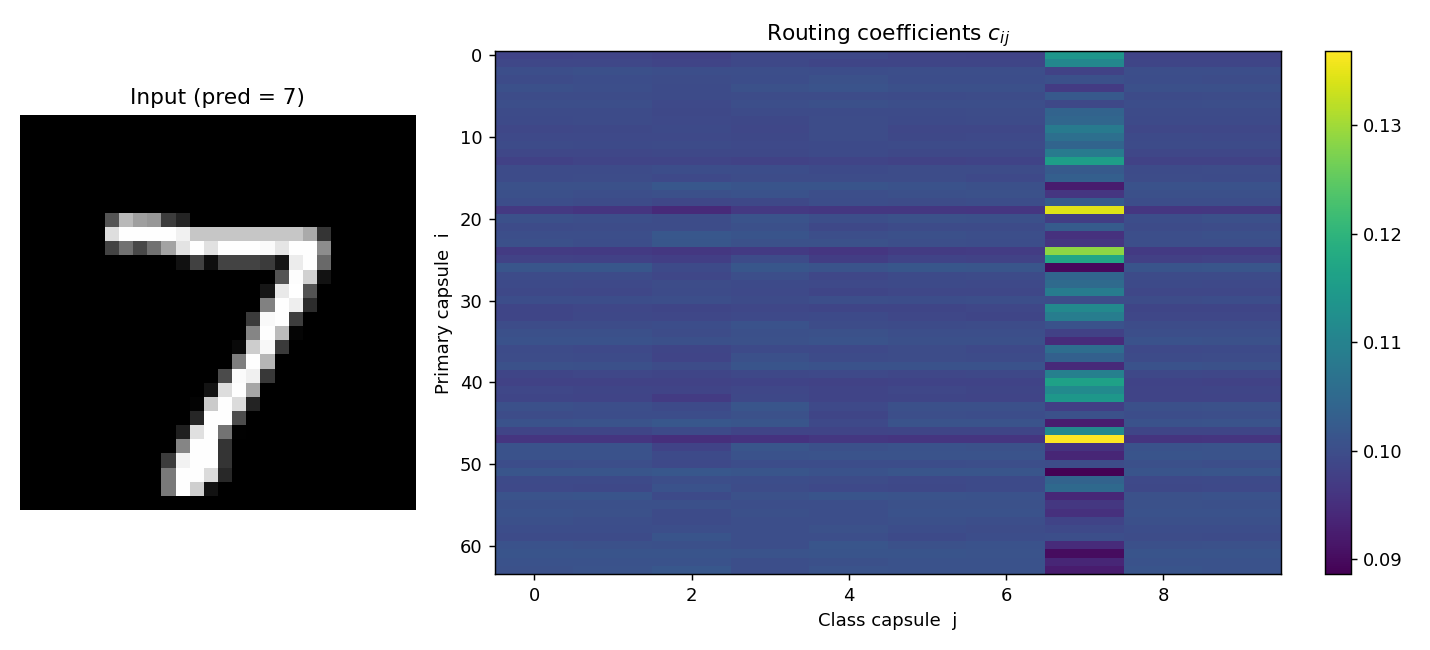

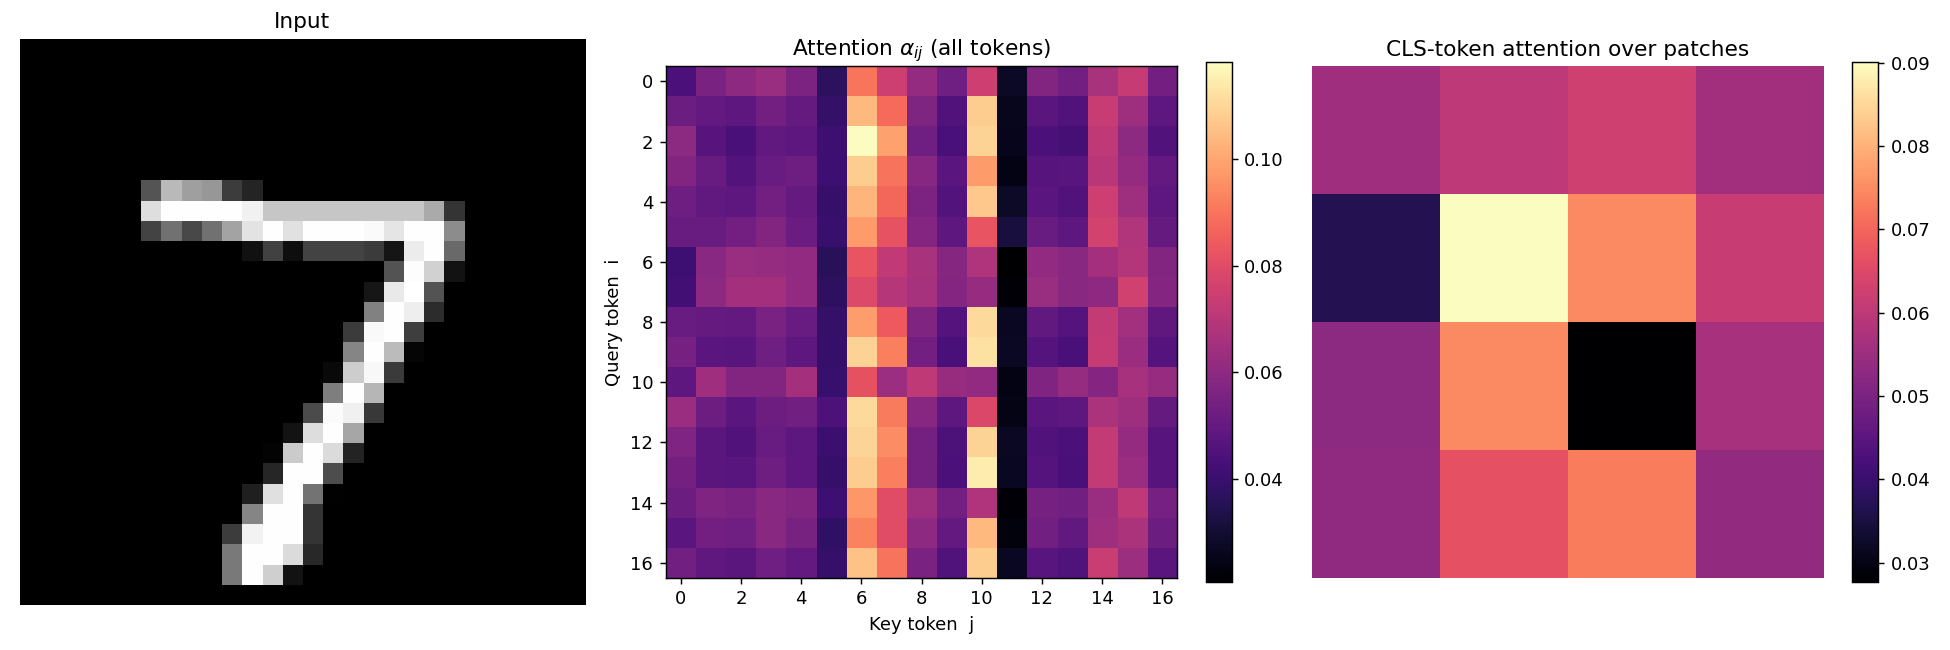

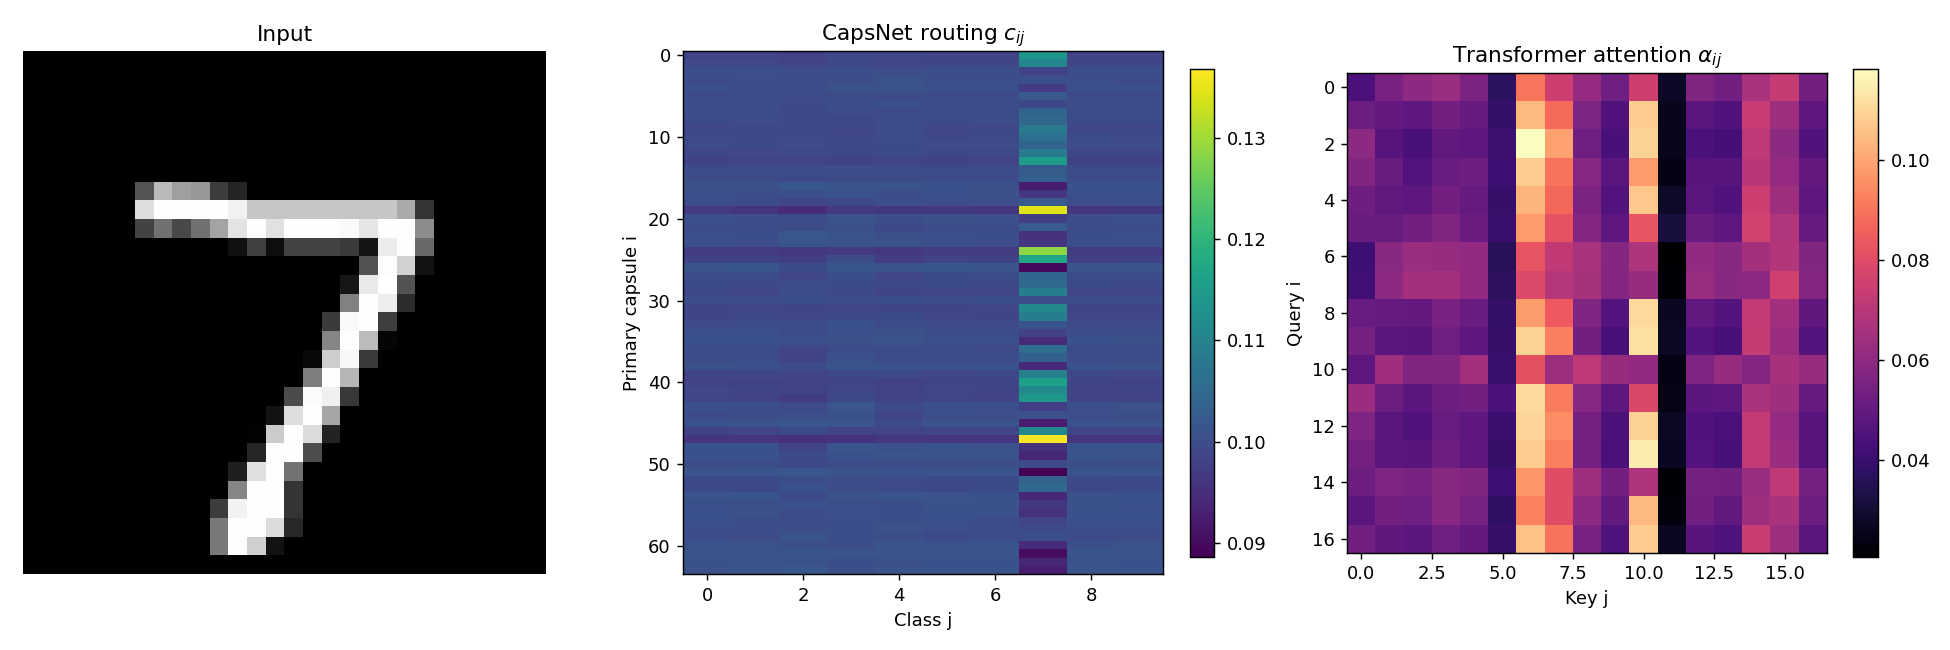

In [15]:
sample = next(iter(make_loaders(train_set, test_set, batch_size=8)[1]))[0]
support  = visualize_routing(caps, sample, device, 'outputs/vizA_routing.png')
sparsity = visualize_attention(vit, sample, device, 'outputs/vizB_attention.png')
side_by_side(caps, vit, sample, device, 'outputs/vizC_side_by_side.png')
print('class support (routing):', support.round(3))
print('attention sparsity:', round(sparsity,3))
from IPython.display import Image, display
for f in ['vizA_routing.png','vizB_attention.png','vizC_side_by_side.png']:
    display(Image('outputs/'+f))


## 12. Experiment 3 — noise robustness
Reuses the trained models; saves `outputs/exp3_noise.png`.


  sigma 0.00 -> CapsNet 0.9940 | ViT 0.9682
  sigma 0.10 -> CapsNet 0.9937 | ViT 0.9581
  sigma 0.20 -> CapsNet 0.9710 | ViT 0.8440
  sigma 0.30 -> CapsNet 0.8198 | ViT 0.5728
  sigma 0.40 -> CapsNet 0.5460 | ViT 0.3772
  sigma 0.50 -> CapsNet 0.3448 | ViT 0.2673


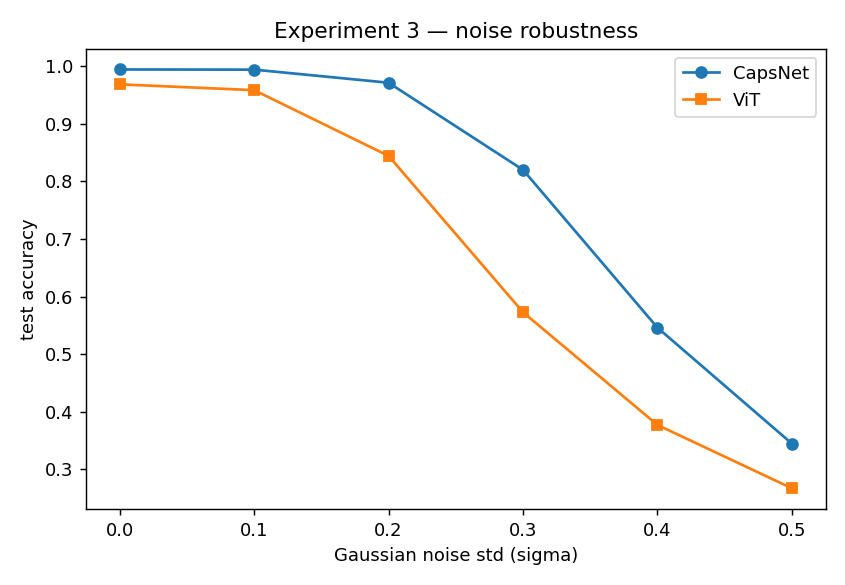

In [16]:
exp3 = experiment3_noise(caps, vit, test_set, device, 'outputs')
from IPython.display import Image, display; display(Image('outputs/exp3_noise.png'))


## 13. Experiment 2 — data efficiency
Retrains from scratch on 10/25/50/100%% of the data (slowest cell).


  fraction  10% -> CapsNet 0.9829 | ViT 0.9052
  fraction  25% -> CapsNet 0.9900 | ViT 0.9454
  fraction  50% -> CapsNet 0.9924 | ViT 0.9646
  fraction 100% -> CapsNet 0.9942 | ViT 0.9727


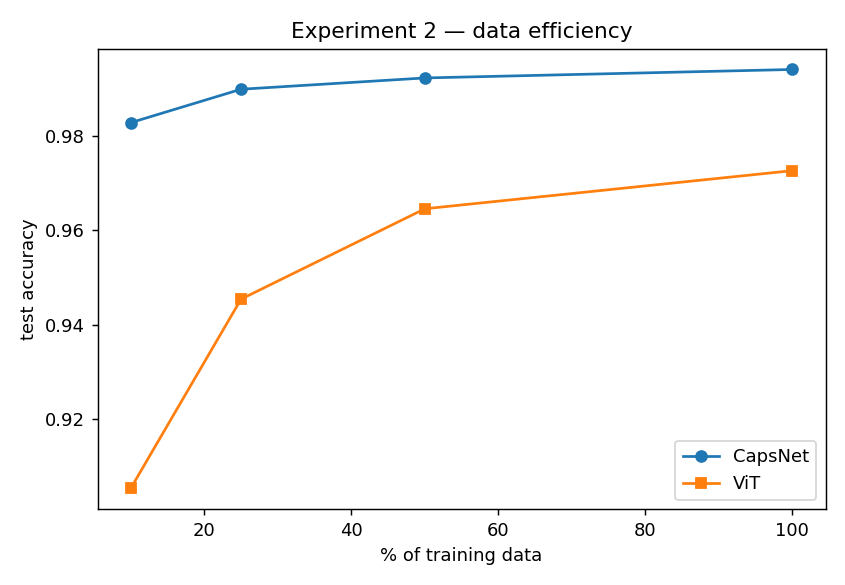

In [17]:
exp2 = experiment2_data_efficiency(build_caps, build_vit, train_set, test_set, device, EPOCHS, 'outputs')
from IPython.display import Image, display; display(Image('outputs/exp2_data_efficiency.png'))


## 14. Save all numeric results


In [18]:
with open('outputs/results.json','w') as f:
    json.dump({'exp1':exp1,'exp2':exp2,'exp3':exp3,'viz':{'class_support':support.tolist(),'attn_sparsity':sparsity}}, f, indent=2)
print('Saved outputs/results.json'); print(sorted(os.listdir('outputs')))

Saved outputs/results.json
['exp1_classification.png', 'exp2_data_efficiency.png', 'exp3_noise.png', 'results.json', 'vizA_routing.png', 'vizB_attention.png', 'vizC_side_by_side.png']


# Advanced Research Component



## Cell A: train the two baselines + two variants and compare (MNIST, 5 epochs):
<b>Why baselines first?</b> Because the ideas only mean something compared to normal:

Idea 1 is interesting only if you can say "it scored X vs normal routing's Y"
Idea 2 is interesting only if you can say "it scored X vs normal attention's Y"

So Cell A gives you the "normal" numbers to compare against. That's all it does.

In [20]:
# --- Advanced Component: bridging experiments on MNIST ---
ADV_EPOCHS = 5
adv_train, adv_test = get_datasets("mnist")
tl, vl = make_loaders(adv_train, adv_test, batch_size=128)

def quick_train(model, epochs=ADV_EPOCHS, caps=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(epochs):
        model.train()
        for x, y in tl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            if caps:
                lengths, _, _ = model(x, y)
                loss = margin_loss(lengths, y)
            else:
                out = model(x); loss = F.cross_entropy(out, y)
            loss.backward(); opt.step()
    # eval
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in vl:
            x, y = x.to(device), y.to(device)
            if caps:
                lengths, _, _ = model(x); pred = lengths.argmax(1)
            else:
                pred = model(x).argmax(1)
            correct += (pred == y).sum().item(); total += y.size(0)
    return correct / total

info = DATASET_INFO["mnist"]
print("Training baseline CapsNet ..."); 
acc_caps = quick_train(CapsuleNetwork(in_channels=1, image_size=28, num_classes=10), caps=True)
print("  CapsNet (normal routing):        %.4f" % acc_caps)

print("Training baseline ViT ...")
acc_vit = quick_train(VisionTransformer(in_channels=1, image_size=28, patch_size=7, num_classes=10))
print("  ViT (single-pass attention):     %.4f" % acc_vit)

Training baseline CapsNet ...
  CapsNet (normal routing):        0.9931
Training baseline ViT ...
  ViT (single-pass attention):     0.9771
